# Which parts of a bursty star-formation history can you actually measure?

> ⚠️ **Experimental.** A research demonstration that explores experimental
> features and may use APIs that change between releases; it sits outside the
> supported tutorial sequence.

Star formation in a real galaxy is **bursty**: it flickers on timescales of tens
to hundreds of megayears. tengri models that directly — a smooth backbone times a
stochastic Gaussian-process *field* whose burstiness is set by a power spectrum:

$$
\mathrm{SFR}(t) \;=\; \underbrace{\mathrm{SFR}_{\mathrm{DPL}}(t)}_{\text{smooth backbone}}
                \times \underbrace{\exp\!\bigl(\mathrm{GP}(t) - \tfrac12 K_0\bigr)}_{\text{bursts}},
\qquad
P(\omega) = \frac{\sigma^2\,\tau}{1 + (\tau\,\omega)^2}.
$$

Fitting such a model raises an uncomfortable question. The field adds one free
parameter per age bin, so it can draw *almost any* history — which means a fit
will always hand you a bursty SFH, whether or not your data said anything about
it. **So which parts of the answer are measurements, and which are the prior
talking back?**

This notebook answers that empirically. We inject **one known bursty history**
into **one galaxy**, then observe that same galaxy three ways:

| | observable | should constrain |
|---|---|---|
| **A** | 7 broadband filters (GALEX FUV → SDSS *z*) | overall shape, stellar mass |
| **B** | the same 7 filters **+ 8 optical emission lines** | the last few Myr, directly |
| **C** | the same 7 filters **+ an *R* = 2000 optical spectrum** | the above, plus the older mass budget |

The truth, the model, the noise level, and the random seed are all held fixed.
The *only* thing that changes between the three fits is what the telescope
measured — so any difference in the recovered history is attributable to the
observable and nothing else.

In [1]:
import warnings

# _setup must be imported BEFORE jax: it sets TF_CPP_MIN_LOG_LEVEL, which XLA only
# reads at import. Import jax first and every cell below carries a wall of
# "PjRt-IFRT does not track XLA executable versions" into the rendered page.
#
# FIG_DIR arrives anchored on _setup's own location, so figures land in
# notebooks/_figs wherever this was started from. The SSP goes through
# tengri.load_ssp for the same reason: a working-directory-relative grid path
# misses silently and falls through to a 67 MB download (#1486).
from _plot_style import setup_style
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()
setup_style()

# Two notices that are correct, and correct to ignore *here*:
#   - a wNE library warns that nebular emission is already in the templates and must
#     be paired with the baked-in backend, which is exactly the pairing used below;
#   - two_component(defaults=FREE) frees the two Calzetti optical depths and reports
#     that Rv, delta, the bump strength and the obscured fraction stay fixed. They
#     belong to other attenuation laws, and holding them constant is the point: this
#     notebook varies the star-formation history, not the dust law.
warnings.filterwarnings("ignore", message=r"(?s).*is a wNE .*")
warnings.filterwarnings("ignore", message=r"(?s).*run with that physics held constant.*")

import time

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FREE,
    Fixed,
    ForwardModel,
    NoiseModel,
    Observation,
    Photometry,
    SEDModel,
    Spectroscopy,
    WavePrecomp,
    builders,
)
from tengri.observation import LineFluxData
from tengri.observation.line_measurement import default_line_defs
from tengri.plot import plot_sfh

# One color per observable, used consistently in every figure below.
C = {"A": "#8c8c8c", "B": "#2f7d3f", "C": "#3a76d9"}
C_TRUTH = "0.05"

## 1. The galaxy, and the three ways we observe it

A **wNE** stellar library bakes nebular emission into the templates, so the
Balmer and forbidden lines that trace the last few megayears come along with the
stellar continuum — no separate emission model, and the line fluxes are
*measured off the model spectrum* the way a pipeline measures data.

In [2]:
SSP_NAME = "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0"
ssp_data = tengri.load_ssp(SSP_NAME)

# An SDSS-like galaxy: GALEX ultraviolet (which is where dust bites) through the
# SDSS optical.
BANDS = ["galex_fuv", "galex_nuv", "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]

# Strong star-forming optical lines. Hgamma and [NII] are left out on purpose:
# they sit on top of stellar Balmer absorption and measure near zero for these
# histories, so their signal-to-noise-scaled errors would feed the fit pure noise.
LINE_NAMES = ["Halpha", "Hbeta", "OIII_5007", "OIII_4959",
              "SII_6717", "SII_6731", "OII_3726", "OII_3729"]

WAVE_OBS = jnp.linspace(3800.0, 9200.0, 260)  # rest 3455-8364 A at z = 0.1

Z_GAL = 0.1
N_GRID = 16  # field latents; Section 1 prints the total dimension they add up to
PHOT_SNR, LINE_SNR, SPEC_SNR = 20.0, 10.0, 30.0

phot = Photometry.from_names(BANDS)
noise_model = NoiseModel(calibration_floor=0.01, student_t_dof=None)

# A template LineFluxData fixes *which* lines the model is built to fit; the
# observed values are filled in per galaxy below.
line_template = LineFluxData.from_dict({nm: (1e-16, 1e-17) for nm in LINE_NAMES})
line_defs = default_line_defs(np.asarray(line_template.wavelengths), tuple(line_template.names))
spec_obs = Spectroscopy(WAVE_OBS, resolution=2000)

# The three observables. Same filters throughout; each adds one thing.
OBSERVATION = {
    "A": Observation(photometry=phot, noise=noise_model),
    "B": Observation(photometry=phot, line_fluxes=line_template, noise=noise_model),
    "C": Observation(photometry=phot, spectroscopy=spec_obs, noise=noise_model),
}
LABEL = {
    "A": f"{len(BANDS)} broadband filters",
    "B": f"{len(BANDS)} filters + {len(LINE_NAMES)} emission lines",
    "C": f"{len(BANDS)} filters + spectrum (R = 2000)",
}


#: The SSP x filter lookup table every fit on this page rides. One instance,
#: shared by all three observables — see the note under the builds below.
FAST_PATH = WavePrecomp()


def build(observation, n_grid=N_GRID, approx=FAST_PATH):
    """The same physical model behind all three fits, on one observable.

    A rising double power law (Carnall et al. 2018) — a galaxy still forming stars,
    not a quiescent one — modulated by the stochastic field. Dust is two-component
    Calzetti with both optical depths free; metallicity and redshift are fixed so
    the comparison isolates the star-formation history.
    """
    return SEDModel.build(
        ssp_data=ssp_data,
        observation=observation,
        sfh={"type": ["dpl", "field"], "all_params": FREE},
        met={"logzsol": Fixed(-0.3)},
        dust=builders.dust.two_component(defaults=FREE, law_bc="calzetti"),
        neb=builders.neb.ssp(),
        redshift=Fixed(Z_GAL),
        apply_igm=False,
        n_grid=n_grid,
        approx=approx,
    )


# Every model here rides the `WavePrecomp` SSP x filter table (the `build` default
# above). It is worth being precise about what that buys, because the per-call
# figure oversells it: one photometry forward pass drops from 6.66 ms to 0.10 ms,
# a factor of 67, for a 3e-4 relative flux change — far inside the S/N 20 noise.
# But the HMC below speeds up by only ~1.4-1.7x (752 s on the exact path against
# 450-550 s here, the spread being machine load), and the MAP fits by 1.4-2.9x,
# because a field-SFH posterior spends most of its time in the
# correlated-field prior and the dense mass matrix — neither of which a photometry
# table touches. Measured per leapfrog step: the SED gradient is 0.51 ms while the
# sampler pays ~7.7 ms, so the table is optimizing well under a tenth of the work.
# The table itself costs ~1 s to build, since the redshift is Fixed and there is no
# z-grid quadrature to pay for.
model = {k: build(v) for k, v in OBSERVATION.items()}
spec = model["B"].spec
fixed_values = spec.get_fixed_values()
print(f"SFH dimension: {spec.n_grid} field latents + {spec.n_free} physical "
      f"= D {spec.n_grid + spec.n_free}")

SFH dimension: 16 field latents + 9 physical = D 25


## 2. One known history, injected

The truth is a rising backbone with a moderately bursty field on top
($\sigma = 0.4$ dex, $\tau = 120$ Myr — the molecular-cloud decorrelation time of
Tacchella, Forbes & Caplar 2020). We rescale the mass so the *mean* present-day
rate is 20 $M_\odot$ yr$^{-1}$, which leaves the rising shape and the bursts
untouched.

In [3]:
SEED = 1
DPL = {"sfh_dpl_alpha": 2.0, "sfh_dpl_beta": 1.5,
       "sfh_dpl_age_gyr": 12.0, "sfh_dpl_tau_gyr": 13.0}

truth = {
    **spec.sample(jax.random.PRNGKey(SEED)),  # a field realization, xi ~ N(0, I)
    **{k: jnp.array(v) for k, v in DPL.items()},
    "met_logzsol": jnp.array(-0.3),
    "dust_tau_bc": jnp.array(0.3),
    "dust_tau_diff": jnp.array(0.15),
    "sfh_field_psd_sigma": jnp.array(0.4),
    "sfh_field_psd_tau_myr": jnp.array(120.0),
    "sfh_dpl_log_total_mass": jnp.array(11.0),
}
_sfh = model["B"].predict_sfh({**fixed_values, **truth})
_now = int(np.argmin(np.asarray(_sfh["t_gyr"])))  # present = smallest lookback time
truth["sfh_dpl_log_total_mass"] = jnp.array(
    11.0 + np.log10(20.0 / float(np.asarray(_sfh["sfr_mean"])[_now]))
)
truth_full = {**fixed_values, **truth}

# Score on the model's OWN log-age nodes, not the default linear resampling: the
# linear grid steps by age_max / n_linear = 13.8 Myr, so only 2 of its samples fall
# below 15 Myr while 5 of the 16 log-age nodes do. Scoring on the linear grid
# weights every megayear equally and lets 15-500 Myr swamp the young bins.
nodes = model["B"].predict_sfh(truth_full, grid="native")
t_node = np.asarray(nodes["t_gyr"])
sfr_true = np.asarray(nodes["sfr_full"])

YOUNG_GYR, MID_GYR = 0.015, 1.0
WINDOW = {
    "recent (< 15 Myr)": t_node < YOUNG_GYR,
    "intermediate (15 Myr - 1 Gyr)": (t_node >= YOUNG_GYR) & (t_node < MID_GYR),
    "old (> 1 Gyr)": t_node >= MID_GYR,
}
print(f"Injected SFH on {t_node.size} log-age nodes, "
      f"{t_node.min() * 1e3:.1f} Myr to {t_node.max():.1f} Gyr")

Injected SFH on 16 log-age nodes, 1.0 Myr to 13.8 Gyr


### Synthesizing the three data sets

Photometry at S/N 20, line fluxes at S/N 10, spectrum at S/N 30 per pixel — all
from the *same* truth, so the three fits differ only in what they are shown.

In [4]:
mock = model["A"].mock({**model["A"].spec.get_fixed_values(), **truth},
                       snr=PHOT_SNR, key=jax.random.PRNGKey(SEED + 10_000))
flux_phot, err_phot = np.asarray(mock.flux_obs), np.asarray(mock.noise)

# measure_line_fluxes needs its line_defs passed explicitly. Left out, it falls
# back to a built-in DESI set of five lines -- not the eight this Observation
# declares -- and the returned array would silently describe different lines.
lf_true = np.asarray(model["B"].measure_line_fluxes(truth_full, line_defs))
assert lf_true[LINE_NAMES.index("Halpha")] > 0, "Halpha not in emission for this truth"
err_line = np.abs(lf_true) / LINE_SNR
flux_line = lf_true + err_line * np.random.default_rng(SEED + 20_000).standard_normal(lf_true.shape)

spec_true = np.asarray(model["C"].predict_spectrum(
    {**model["C"].spec.get_fixed_values(), **truth}, wave_obs=WAVE_OBS))
err_spec = np.abs(spec_true) / SPEC_SNR
flux_spec = spec_true + err_spec * np.random.default_rng(SEED + 30_000).normal(size=spec_true.shape)

# Fold the measured values into the observations the fits will actually see.
line_data = LineFluxData(names=tuple(LINE_NAMES), fluxes=jnp.asarray(flux_line),
                         errors=jnp.asarray(err_line), wavelengths=line_template.wavelengths)
OBSERVATION["B"] = Observation(photometry=phot, line_fluxes=line_data, noise=noise_model)

DATA = {
    "A": (flux_phot, err_phot),
    "B": (flux_phot, err_phot),
    # Photometry and spectrum arrive as one concatenated vector; the Observation
    # already declares both, so the split is unambiguous.
    "C": (np.concatenate([flux_phot, flux_spec]), np.concatenate([err_phot, err_spec])),
}
print(f"A: {flux_phot.size} fluxes   "
      f"B: {flux_phot.size} + {flux_line.size} lines   "
      f"C: {flux_phot.size} + {flux_spec.size} spectral pixels")

A: 7 fluxes   B: 7 + 8 lines   C: 7 + 260 spectral pixels


### What each observable sees

The faint gray curve is the same true spectrum in all three panels. Only the
markers change.

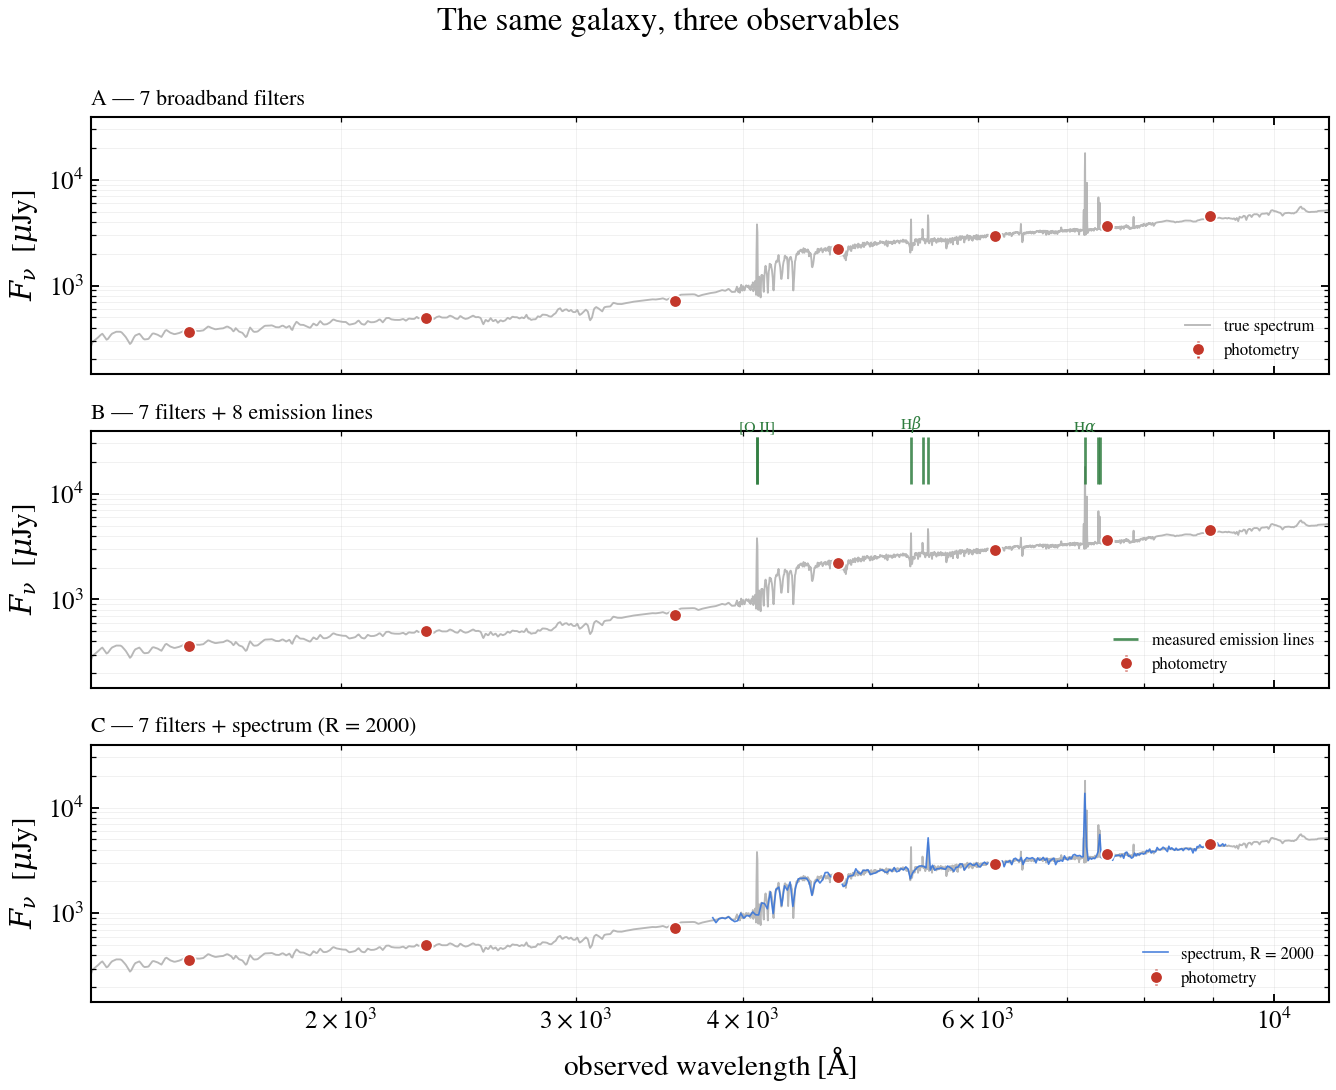

In [5]:
wave_wide = jnp.linspace(1300.0, 11000.0, 3000)
sed_wide = np.asarray(model["C"].predict_spectrum(
    {**model["C"].spec.get_fixed_values(), **truth}, wave_obs=wave_wide))
TO_UJY = 1e29  # erg/s/cm2/Hz -> microjansky
wave_eff = np.asarray(effective_wavelengths_um(phot)) * 1e4

X_LO, X_HI = 1300.0, 11000.0
# Set the limits from the noiseless SED, not from the data. The noisy spectrum has
# pixels scattered close to zero, and on a shared log axis those would drag the
# lower limit down two decades and leave every panel mostly empty.
_shown = (np.asarray(wave_wide) >= X_LO) & (np.asarray(wave_wide) <= X_HI)
Y_LO = float(np.nanmin(sed_wide[_shown])) * TO_UJY * 0.55
Y_HI = float(np.nanmax(sed_wide[_shown])) * TO_UJY * 2.2

# Three well-separated lines to name. [O III] 5007 is deliberately left unlabeled:
# at this width its tick sits ~160 A from Hbeta and the two labels overlap into
# nonsense. All eight are still drawn.
NAMED = {"OII_3726": "[O II]", "Hbeta": r"H$\beta$", "Halpha": r"H$\alpha$"}

fig, axes = plt.subplots(3, 1, figsize=(9.2, 7.4), sharex=True, sharey=True)
for key, ax in zip("ABC", axes):
    ax.plot(np.asarray(wave_wide), sed_wide * TO_UJY, color="0.72", lw=0.9, zorder=1,
            label="true spectrum" if key == "A" else None)
    if key == "C":
        ax.plot(np.asarray(WAVE_OBS), flux_spec * TO_UJY, color=C["C"], lw=0.8,
                alpha=0.9, zorder=2, label="spectrum, R = 2000")
    if key == "B":
        obs_wl = np.asarray(line_template.wavelengths) * (1 + Z_GAL)
        ax.vlines(obs_wl, Y_HI / 3.2, Y_HI / 1.15, color=C["B"], lw=1.3, alpha=0.85,
                  zorder=3, label="measured emission lines")
        for nm, tex in NAMED.items():
            ax.text(obs_wl[LINE_NAMES.index(nm)], Y_HI / 1.08, tex, color=C["B"],
                    fontsize=7.5, ha="center", va="bottom")
    ax.errorbar(wave_eff, flux_phot * TO_UJY, yerr=err_phot * TO_UJY, fmt="o", ms=6,
                color="#c3372a", mec="w", mew=0.8, lw=1.2, zorder=4, label="photometry")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel(r"$F_\nu$  [$\mu$Jy]")
    ax.set_title(f"{key} — {LABEL[key]}", loc="left", fontsize=10.5)
    ax.legend(fontsize=8, loc="lower right", framealpha=0.92)
    ax.grid(alpha=0.2, which="both", lw=0.4)
axes[-1].set_xlabel(r"observed wavelength [$\mathrm{\AA}$]")
axes[-1].set_xlim(X_LO, X_HI)
axes[-1].set_ylim(Y_LO, Y_HI)
fig.suptitle("The same galaxy, three observables", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "sfh_observables.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Fit all three

One call each, through the canonical `ForwardModel.fit` surface. The models were
built without an `approx=` argument, so **predictions stay exact**; the fit picks
its own lookup-table acceleration (`approx="auto"` is the default) based on what
the observation declares.

We use a MAP fit here: it is the cheap, robust way to ask *where does the mode
land*, which is exactly the question a three-way comparison needs. Section 5
adds a full posterior for the middle case.

In [6]:
fits, timings = {}, {}
for key in "ABC":
    obs = OBSERVATION[key]
    m = build(obs)
    data, err = DATA[key]
    t0 = time.perf_counter()
    fits[key] = ForwardModel.build(sed=m, observation=obs).fit(
        data, err, method="map", n_steps=10_000, n_restarts=3,
        key=jax.random.PRNGKey(SEED), verbose=False,
    )
    timings[key] = time.perf_counter() - t0
    model[key] = m
    print(f"{key}: MAP in {timings[key]:5.1f} s")

A: MAP in   7.4 s


B: MAP in 188.5 s


C: MAP in  18.2 s


## 4. What came back

Two numbers per fit, both computed on the model's native log-age nodes:

- **RMS error in dex**, per age window — how well the *shape* of the history is
  recovered.
- **Old mass fraction**, the fraction of stellar mass formed more than 1 Gyr ago
  — the *mass budget*. This is the honest way to score the old population: past
  ~1 Gyr a rising history has near-zero SFR, so a per-node log ratio there is set
  by whichever value sits closer to zero and can look *worse* as the data
  improve. Mass is bounded and is what a paper actually reports.

In [7]:
def sfr_at_nodes(key):
    """MAP star-formation rate on the native log-age nodes [Msun/yr]."""
    p = {**model[key].spec.get_fixed_values(), **fits[key].params}
    return np.asarray(model[key].predict_sfh(p, grid="native")["sfr_full"])


def rms_dex(pred, mask):
    lo = 1e-8
    return float(np.sqrt(np.mean(
        (np.log10(np.clip(pred[mask], lo, None)) - np.log10(np.clip(sfr_true[mask], lo, None))) ** 2
    )))


def old_mass_fraction(sfr):
    """Fraction of stellar mass formed more than 1 Gyr ago."""
    order = np.argsort(t_node)
    t, s = t_node[order], np.asarray(sfr)[order]
    total = np.trapezoid(s, t)
    old = t > MID_GYR
    return float(np.trapezoid(s[old], t[old]) / total) if total > 0 else np.nan


sfr_map = {k: sfr_at_nodes(k) for k in "ABC"}
score = {
    k: {name: rms_dex(sfr_map[k], mask) for name, mask in WINDOW.items()}
    | {"f_old": old_mass_fraction(sfr_map[k])}
    for k in "ABC"
}
f_old_true = old_mass_fraction(sfr_true)

print(f"{'':38s}{'recent':>9s}{'interm.':>9s}{'f_old':>9s}")
print("-" * 65)
for k in "ABC":
    s = score[k]
    print(f"{k} {LABEL[k]:36s}"
          f"{s['recent (< 15 Myr)']:>9.3f}"
          f"{s['intermediate (15 Myr - 1 Gyr)']:>9.3f}"
          f"{s['f_old']:>9.3f}")
print(f"{'':38s}{'':>9s}{'':>9s}{f_old_true:>9.3f}  <- truth")

                                         recent  interm.    f_old
-----------------------------------------------------------------
A 7 broadband filters                     0.297    0.295    0.759
B 7 filters + 8 emission lines            0.056    0.267    0.779
C 7 filters + spectrum (R = 2000)         0.113    0.321    0.805
                                                            0.798  <- truth


### The recovered histories

A **linear** rate axis on a **log** time axis. Linear in rate because that is
what a mass budget cares about — log-y flatters a reconstruction by making a
factor-of-three miss at low SFR look like a small offset. Log in time because
the recent bins under test are five of sixteen nodes and would be crushed into
the left edge of a linear axis.

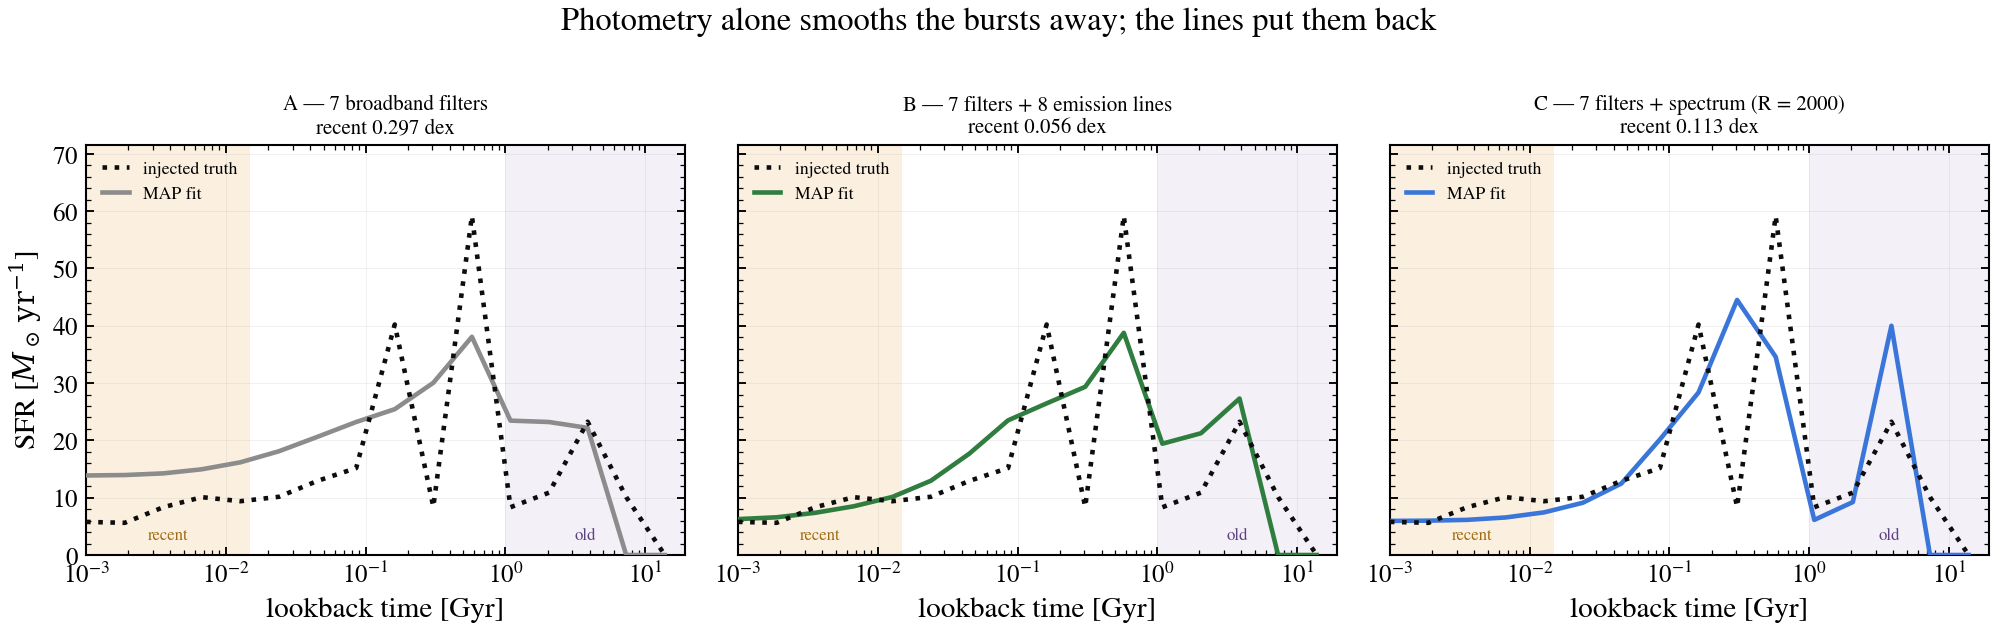

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.3), sharey=True)
top = float(np.nanmax([sfr_true.max()] + [sfr_map[k].max() for k in "ABC"])) * 1.12
t_plot = np.clip(t_node, 1e-3, None)

for key, ax in zip("ABC", axes):
    ax.axvspan(t_plot.min(), YOUNG_GYR, color="#e8a33d", alpha=0.16, lw=0)
    ax.axvspan(MID_GYR, t_plot.max() * 1.4, color="#8f6fb5", alpha=0.10, lw=0)
    ax.plot(t_plot, sfr_true, color=C_TRUTH, lw=2.2, ls=":", label="injected truth", zorder=4)
    ax.plot(t_plot, sfr_map[key], color=C[key], lw=2.2, label="MAP fit", zorder=3)
    ax.set_xscale("log")
    ax.set_xlim(t_plot.min(), t_plot.max() * 1.4)
    ax.set_ylim(0, top * 1.08)
    ax.set_xlabel("lookback time [Gyr]")
    ax.set_title(f"{key} — {LABEL[key]}\nrecent {score[key]['recent (< 15 Myr)']:.3f} dex",
                 fontsize=10)
    ax.legend(fontsize=8.5, loc="upper left", framealpha=0.92)
    ax.grid(alpha=0.22, lw=0.4)
axes[0].set_ylabel(r"SFR [$M_\odot\,\mathrm{yr}^{-1}$]")
# Window labels sit at the FOOT of each shaded band: at the top they collide with
# the legend, and the SFR curves never come near the floor on the left.
for _ax in axes:
    _ax.text(np.sqrt(t_plot.min() * YOUNG_GYR), top * 0.03, "recent", fontsize=8,
             color="#a06a10", ha="center", va="bottom")
    _ax.text(np.sqrt(MID_GYR * t_plot.max()), top * 0.03, "old", fontsize=8,
             color="#5c4080", ha="center", va="bottom")
fig.suptitle("Photometry alone smooths the bursts away; the lines put them back", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "sfh_recovery_by_observable.png", dpi=150, bbox_inches="tight")
plt.show()

### The scorecard

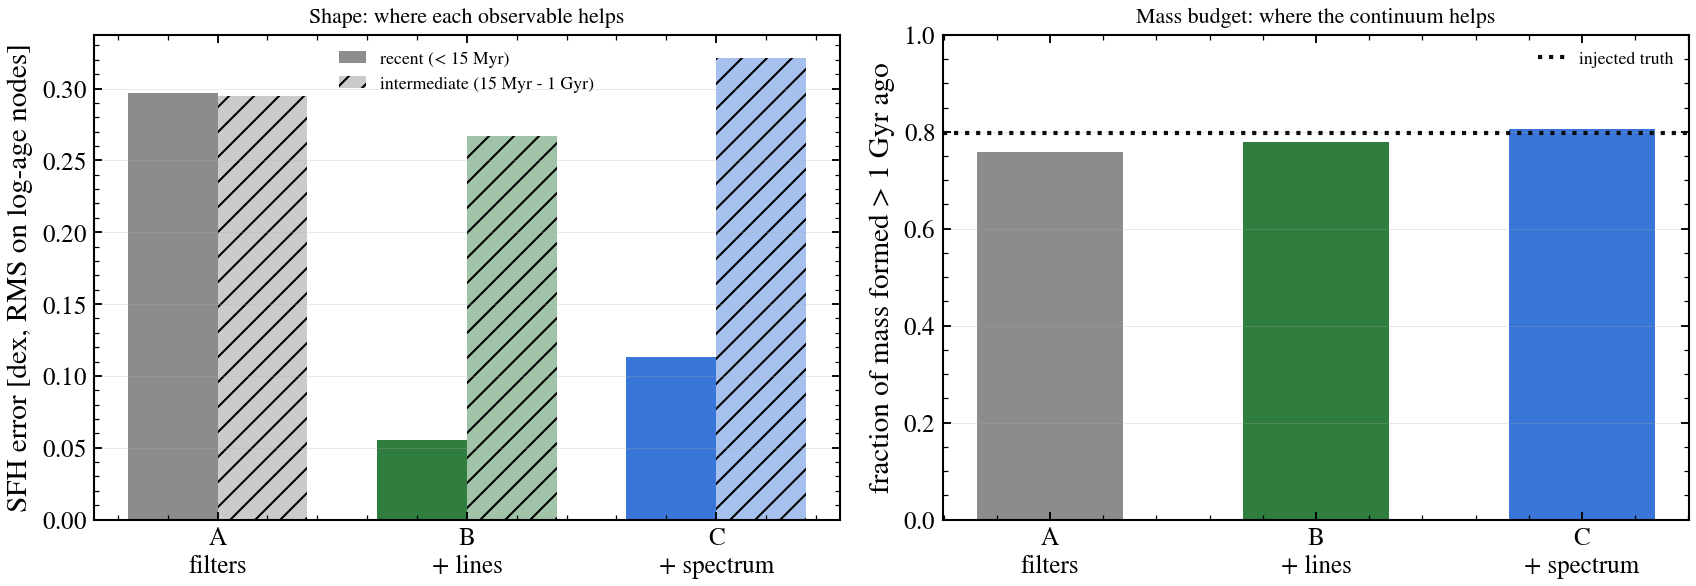

In [9]:
fig, (ax_dex, ax_mass) = plt.subplots(1, 2, figsize=(11.6, 4.2))
x = np.arange(3)
w = 0.36
for i, (name, off) in enumerate((("recent (< 15 Myr)", -w / 2),
                                ("intermediate (15 Myr - 1 Gyr)", +w / 2))):
    ax_dex.bar(x + off, [score[k][name] for k in "ABC"], w,
               color=[C[k] for k in "ABC"], alpha=1.0 if i == 0 else 0.45,
               hatch=None if i == 0 else "//", label=name)
ax_dex.set_xticks(x)
ax_dex.set_xticklabels(["A\nfilters", "B\n+ lines", "C\n+ spectrum"])
ax_dex.set_ylabel("SFH error [dex, RMS on log-age nodes]")
ax_dex.set_title("Shape: where each observable helps", fontsize=10.5)
ax_dex.legend(fontsize=8.5)
ax_dex.grid(axis="y", alpha=0.3, lw=0.4)

ax_mass.bar(x, [score[k]["f_old"] for k in "ABC"], 0.55, color=[C[k] for k in "ABC"])
ax_mass.axhline(f_old_true, color=C_TRUTH, ls=":", lw=2.0, label="injected truth")
ax_mass.set_xticks(x)
ax_mass.set_xticklabels(["A\nfilters", "B\n+ lines", "C\n+ spectrum"])
ax_mass.set_ylabel("fraction of mass formed > 1 Gyr ago")
ax_mass.set_ylim(0, 1)
ax_mass.set_title("Mass budget: where the continuum helps", fontsize=10.5)
ax_mass.legend(fontsize=8.5)
ax_mass.grid(axis="y", alpha=0.3, lw=0.4)

fig.tight_layout()
fig.savefig(FIG_DIR / "sfh_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. A full posterior, not just a mode

The MAP comparison above answers *where does the mode land*. It says nothing
about how wide the answer is — and with 15 measured numbers (7 fluxes, 8 lines)
constraining a model of the dimension printed in Section 1, the width is the
interesting part. So we run a Hamiltonian Monte Carlo posterior on case **B** and
plot it with the library helper.

One caveat, and it is larger than this page used to admit. The posterior is
wide and strongly correlated (mass ↔ SFR, dust ↔ recent SFR), so it needs a long
trajectory: `n_leapfrog_steps=100`, where the default of 10 under-explores and
returns deceptively tight bands. And the non-centered field rotates with $\tau$,
so the curvature is position-dependent and one global mass matrix cannot
represent it.

The cell below now prints the diagnostic, and it does not pass: **$\hat{R}
\approx 1.6$** at this budget, on a $D=25$ posterior, with a handful of
divergences. A stable integrator and a large $\hat{R}$ together say the chains
are each sampling something, but not the same thing. So the bands below are
**not credible intervals** — read the recovered SFH *shape* against the truth,
which is what this page is for, and do not read the widths.

More sampling is not the fix *at this budget*, and this was measured rather than
assumed: quadrupling the warmup exhausts memory before it converges. Confirmed
again while investigating #1743 — 1200 warmup x 100 leapfrog with a dense mass
matrix is SIGKILLed on the machine this page is developed on.

**Two plausible fixes were tried and are worse — do not reach for them (#1743).**
Both were measured on a matched $D=25$ field model:

- **Reparameterizing the field.** `sfh={'field_centering': a}` (#1355) moves the
  amplitude dependence out of the non-centered map, which is the obvious reading
  of "the field rotates with $\tau$". Measured: `a=1.0` (the default,
  non-centered) gives $\hat{R}$ 1.10, while `a=0.5` and `a=0.0` both give
  **2.54** — with *zero* divergences, the signature of chains that stopped moving
  rather than chains that mix. The non-centered coordinates are what makes this
  fit work. Centering it walks into Neal's funnel, which is the standard reason
  non-centered is the default for hierarchical and GP models.
- **geoVI / MGVI.** The natural-looking tool for position-dependent curvature.
  Measured on the same model: ~12x slower than HMC at a matched budget, and
  `chi2/dof ~ 35` at 5, 15 and 30 iterations alike — flat, so it is not
  converging slowly, it is not converging. It samples in the same coordinates
  HMC does, which is the likely reason it inherits the same difficulty.

**What did help**, on that matched model: more warmup (300 -> 600 took $\hat{R}$
from 1.10 to 1.02) and `mcmc_nuts`, which adapts trajectory length instead of
fixing it (1.014). Neither is wired in here — this page's budget is chosen to
run in minutes, and the higher-warmup variant exceeds this machine's memory —
but they are the directions to take if you need a posterior you can quote.

In [10]:
# Cost is (n_warmup + n_samples) x n_leapfrog_steps gradient evaluations, so the
# trajectory length is the expensive knob -- and the one that matters here, since a
# short trajectory returns tight bands that are an artifact of not having moved.
# This is a demonstration budget chosen to run in minutes; a result you intend to
# publish wants several times the samples and a convergence check.
t0 = time.perf_counter()
posterior = ForwardModel.build(sed=model["B"], observation=OBSERVATION["B"]).fit(
    *DATA["B"], method="mcmc_hmc", init_from=fits["B"],
    n_warmup=300, n_samples=200, n_leapfrog_steps=100, dense_mass_matrix=True,
    key=jax.random.PRNGKey(SEED + 7), verbose=False,
)
print(f"HMC in {time.perf_counter() - t0:.0f} s")

HMC in 547 s


HMC diagnostics: 1 divergences, max R-hat 1.6226
  ⚠ WARNING: Posterior may not have converged properly. For publication, increase n_warmup and n_leapfrog_steps.


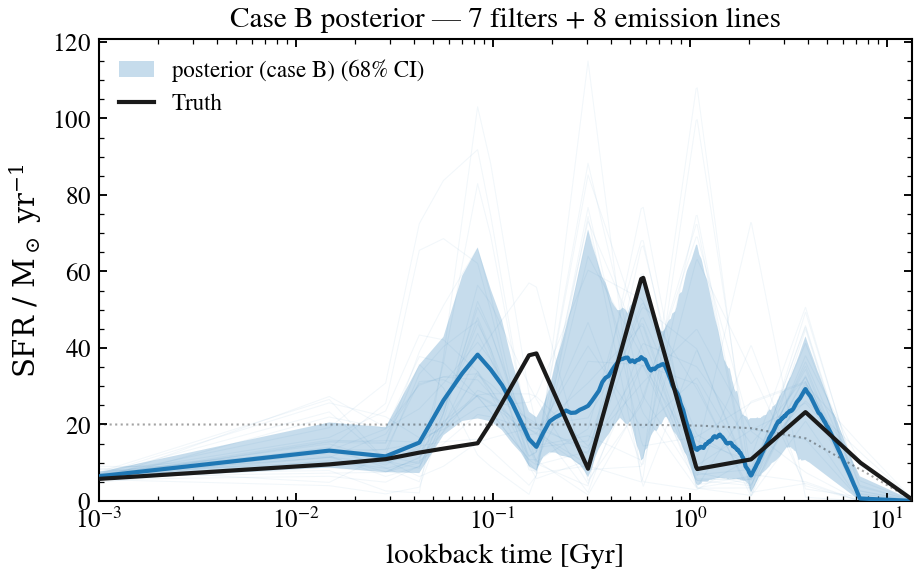

In [11]:
# Check convergence: are the draws actually distinct and properly mixed?
diag = posterior.diagnostics
n_div = diag.get("n_divergent", 0)
max_rhat = float(np.nanmax(list(posterior.rhat().values())))
print(f"HMC diagnostics: {n_div} divergences, max R-hat {max_rhat:.4f}")
if n_div > 0 or max_rhat > 1.01:
    print("  ⚠ WARNING: Posterior may not have converged properly. "
          "For publication, increase n_warmup and n_leapfrog_steps.")

ax = plot_sfh(model["B"], posterior, true_params=truth_full,
              method="HMC", xscale="log", label="posterior (case B)")
ax.set_title("Case B posterior — 7 filters + 8 emission lines")
ax.set_xlabel("lookback time [Gyr]")
ax.figure.savefig(FIG_DIR / "sfh_posterior_lines.png", dpi=150, bbox_inches="tight")
plt.show()

Read that figure carefully, because it shows the failure as well as the success.
Below ~0.1 Gyr the posterior tracks the injected history and the band is
honestly narrow — that is the emission lines doing their work. Between 0.1 and
1 Gyr the band is *too* narrow: the truth sits outside it at the burst peaks,
so those intervals under-cover rather than merely being wide.

That is the geometry problem named above, not a budget problem, and it is the
concrete reason for the advice in the next section — quote integrated
quantities, whose errors are dominated by the well-measured part of the
history, rather than the star-formation rate in an individual age bin.

## What to take away

**1. Emission lines are the biggest single win, and extra filters are not.**
Adding 8 optical lines to the *same* 7 filters is what fixes the recent history:
a factor of five below 15 Myr for the galaxy above (0.30 → 0.06 dex), and 0.37 →
0.10 dex as a median over three independent realizations. Widening the *filter*
set instead, to
a COSMOS-like 20 bands with medium bands included, leaves that number essentially
unchanged. Broadband photometry integrates over the young light; the lines measure
it. For an SDSS-like sample the spectrum is the whole game and extra filters add
almost nothing.

**2. The spectrum's distinctive contribution is the old mass budget.** The
fraction of mass formed more than 1 Gyr ago improves monotonically from A to C and
lands on the truth once the continuum is included — the same ordering as the
three-realization study (truth 0.798; 0.758 photometry, 0.780 with lines, 0.804
with a spectrum). The 4000 Å break and Balmer absorption carry that information
and a list of line fluxes throws it away.

**3. Below 15 Myr, lines and a spectrum are equivalent — and one galaxy cannot
rank them.** That equivalence is expected: the lines *are* the part of the
spectrum carrying recent-SFH information, and over three realizations both give
0.10 dex. The intermediate window (15 Myr – 1 Gyr) is noisier still. In the single
galaxy above the spectrum happens to score *worst* of the three there, while the
three-realization medians put lines and spectrum within 0.01 dex of each other and
both ahead of photometry alone. Read the direction of these effects, not the
ordering of one realization.

**4. Report integrals, not per-node rates.** The old population's *mass* is well
measured even where its per-node *SFR* is not constrained at all — which is why
the mass-fraction panel is meaningful while a per-node comparison beyond 1 Gyr is
not. Quote physically defined integrals — SFR averaged over 0–10 and 0–100 Myr,
$M_\star$, mass-weighted age — rather than the star-formation rate in an
individual age bin.

**5. More age bins do not mean more resolution.** `n_grid` sets how *smooth* the
field is, not how much the data can say: quadrupling it from 16 to 64 leaves the
recovered information flat while tripling the dimension a sampler has to explore.
`n_grid=32` is a good default — as smooth as 64, and small enough that HMC still
behaves.

### Scope of this demonstration

One galaxy, one burstiness ($\sigma = 0.4$ dex), one redshift, and a pessimistic
line signal-to-noise of 10. The population-level versions of these
experiments — paired photometry-versus-lines contrasts, the burstiness ladder,
and the `n_grid` sweep — live in `scripts/field_sfh_recovery_study.py`, which is
where the multi-realization numbers quoted above come from:

```bash
python scripts/field_sfh_recovery_study.py --stage paired
python scripts/field_sfh_recovery_study.py --stage spectrum --n-seeds 15
```

**Provenance.** Every number here was re-measured after #1271, which fixed a
silent failure in which the field latents reached neither the likelihood nor the
returned posterior — so all pre-fix recovery numbers described the prior, not the
data. Earlier versions of this notebook claimed the truth sat inside the 95%
band at all lookback times and that the burstiness $\sigma$ was recovered from
photometry alone. Both were artifacts of that bug and are retracted.